# TELECOMMUNICATION CHURN PROJECT

## Problem Understanding

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
sns.set(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')



## Load data

In [2]:
df=pd.read_excel("P670-dataset.xlsx")
df.drop('Unnamed: 0', axis=1, inplace=True)

df.head()

,state,area.code,account.length,voice.plan,voice.messages,intl.plan,intl.mins,intl.calls,intl.charge,day.mins,day.calls,day.charge,eve.mins,eve.calls,eve.charge,night.mins,night.calls,night.charge,customer.calls,churn
0,KS,area_code_415,128,yes,25,no,10.0,3,2.70,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,1,no
1,OH,area_code_415,107,yes,26,no,13.7,3,3.70,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,1,no
2,NJ,area_code_415,137,no,0,no,12.2,5,3.29,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,0,no
3,OH,area_code_408,84,no,0,yes,6.6,7,1.78,299.4,71,50.9,61.9,88,5.26,196.9,89,8.86,2,no
4,OK,area_code_415,75,no,0,yes,10.1,3,2.73,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,3,no


### Basic information

In [3]:
print("\nInfo:")
print(df.info())


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   state           5000 non-null   object 
 1   area.code       5000 non-null   object 
 2   account.length  5000 non-null   int64  
 3   voice.plan      5000 non-null   object 
 4   voice.messages  5000 non-null   int64  
 5   intl.plan       5000 non-null   object 
 6   intl.mins       5000 non-null   float64
 7   intl.calls      5000 non-null   int64  
 8   intl.charge     5000 non-null   float64
 9   day.mins        5000 non-null   float64
 10  day.calls       5000 non-null   int64  
 11  day.charge      5000 non-null   object 
 12  eve.mins        5000 non-null   object 
 13  eve.calls       5000 non-null   int64  
 14  eve.charge      5000 non-null   float64
 15  night.mins      5000 non-null   float64
 16  night.calls     5000 non-null   int64  
 17  night.charge    5000 non-n

In [4]:
print("\nColumns:\n", df.columns)


Columns:
 Index(['state', 'area.code', 'account.length', 'voice.plan', 'voice.messages',
       'intl.plan', 'intl.mins', 'intl.calls', 'intl.charge', 'day.mins',
       'day.calls', 'day.charge', 'eve.mins', 'eve.calls', 'eve.charge',
       'night.mins', 'night.calls', 'night.charge', 'customer.calls', 'churn'],
      dtype='object')


In [5]:
print("Shape:", df.shape)

Shape: (5000, 20)


In [6]:
print("\nDescription:\n", df.describe())


Description:
        account.length  voice.messages    intl.mins   intl.calls  intl.charge  \
count      5000.00000     5000.000000  5000.000000  5000.000000  5000.000000   
mean        100.25860        7.755200    10.261780     4.435200     2.771196   
std          39.69456       13.546393     2.761396     2.456788     0.745514   
min           1.00000        0.000000     0.000000     0.000000     0.000000   
25%          73.00000        0.000000     8.500000     3.000000     2.300000   
50%         100.00000        0.000000    10.300000     4.000000     2.780000   
75%         127.00000       17.000000    12.000000     6.000000     3.240000   
max         243.00000       52.000000    20.000000    20.000000     5.400000   

          day.mins    day.calls    eve.calls   eve.charge   night.mins  \
count  5000.000000  5000.000000  5000.000000  5000.000000  5000.000000   
mean    180.288900   100.029400   100.191000    17.054322   200.391620   
std      53.894699    19.831197    19.8264

## Checking Missing values

In [7]:
### Checking missing values
print(df.isnull().sum())

state             0
area.code         0
account.length    0
voice.plan        0
voice.messages    0
intl.plan         0
intl.mins         0
intl.calls        0
intl.charge       0
day.mins          0
day.calls         0
day.charge        0
eve.mins          0
eve.calls         0
eve.charge        0
night.mins        0
night.calls       0
night.charge      0
customer.calls    0
churn             0
dtype: int64


### Checking Duplicates

In [8]:
print("\nDuplicate Rows:", df.duplicated().sum())


Duplicate Rows: 0


###  Drop irrelevant columns

In [9]:
for col in ['Unnamed: 0', 'state']:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

### Target Distribution

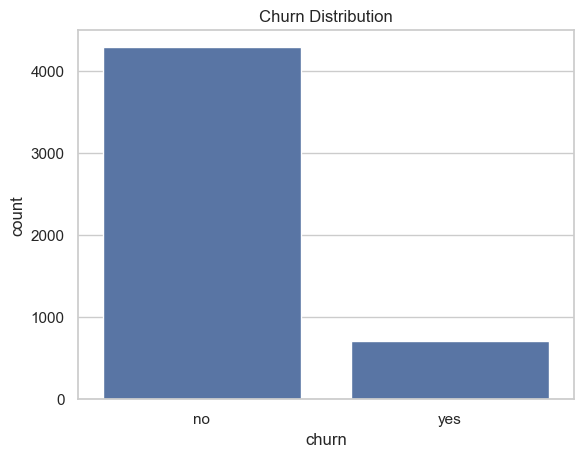

In [10]:
sns.countplot(x='churn', data=df)
plt.title("Churn Distribution")
plt.show()


### Univariant Analysis

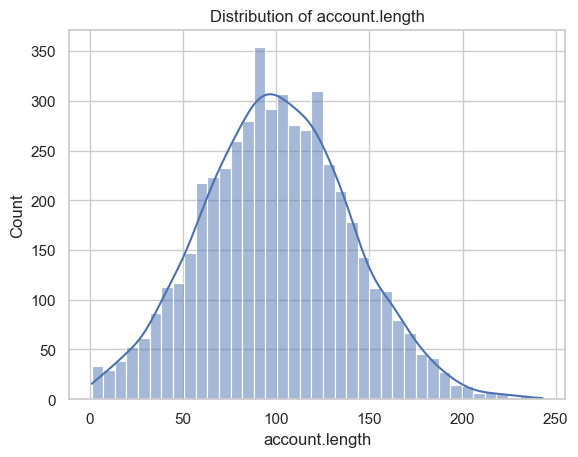

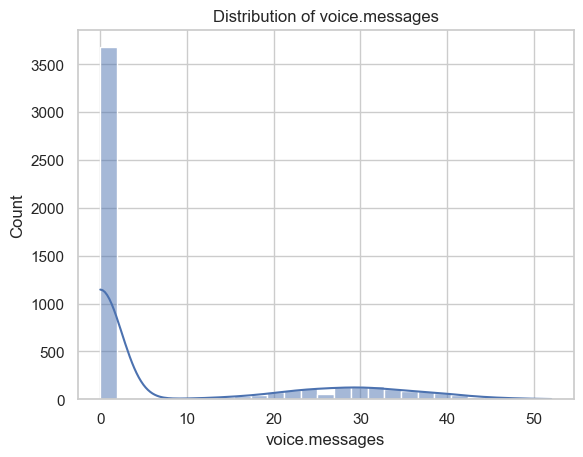

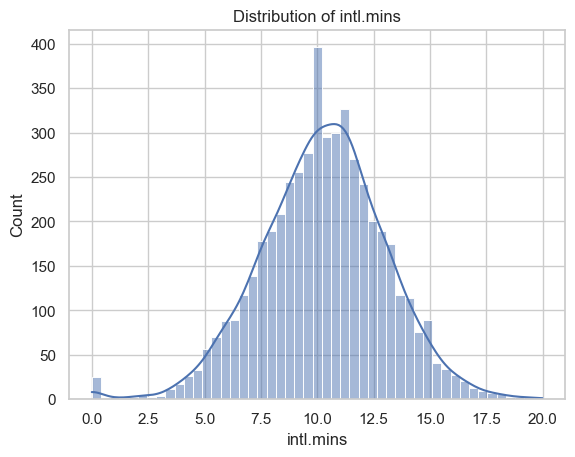

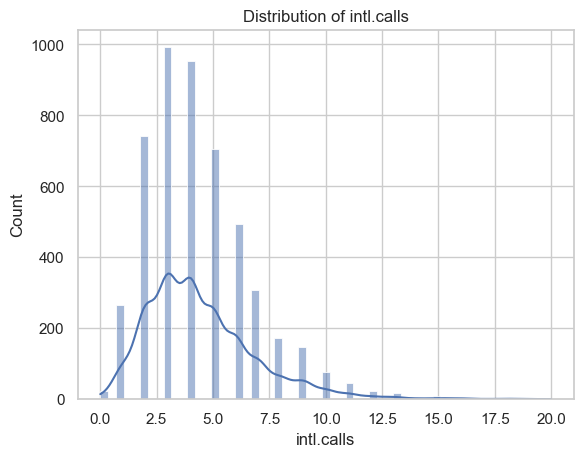

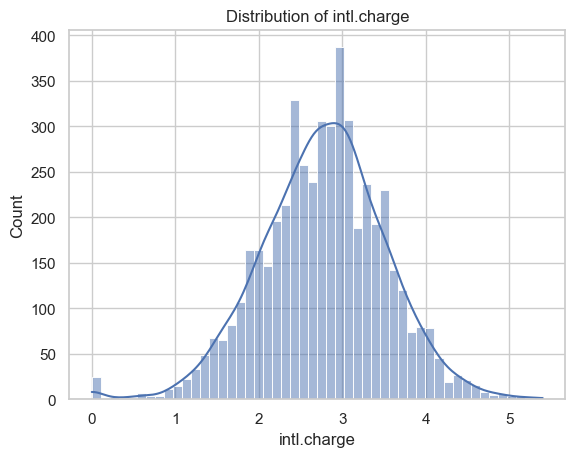

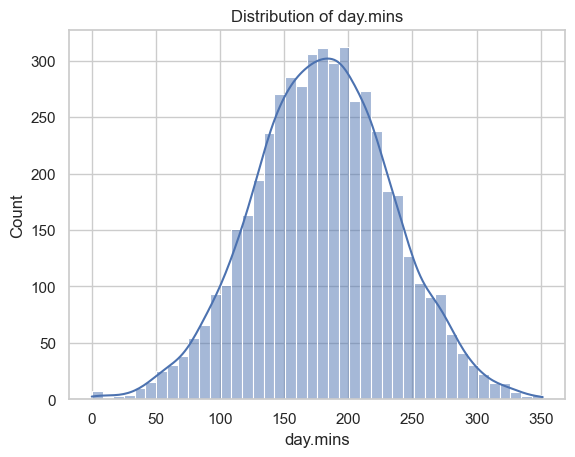

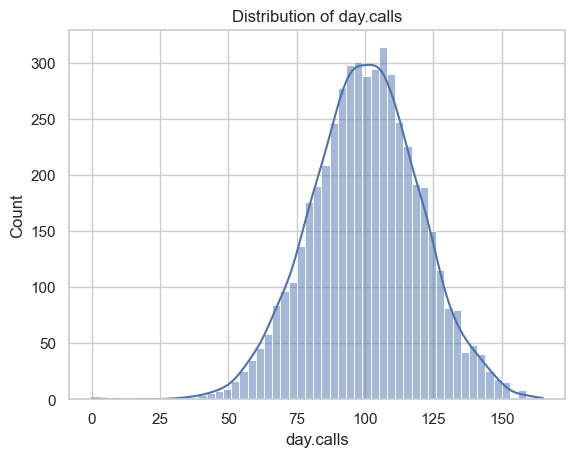

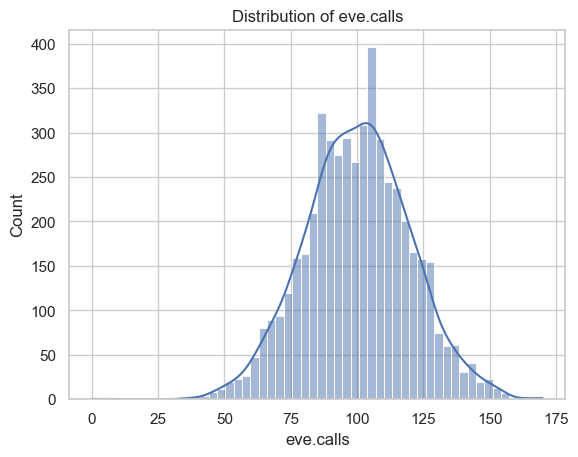

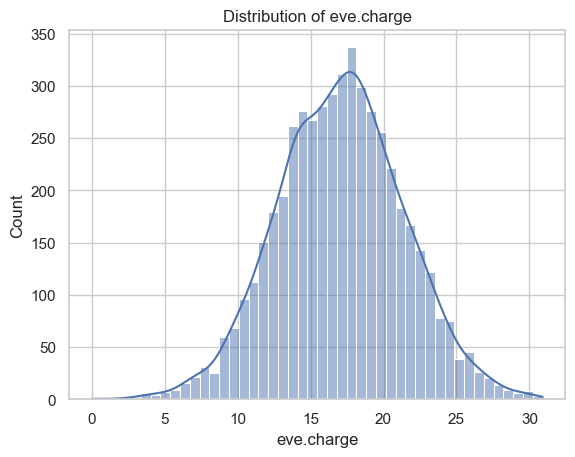

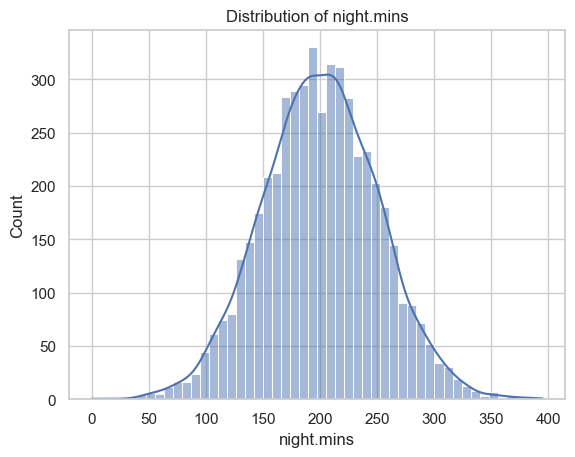

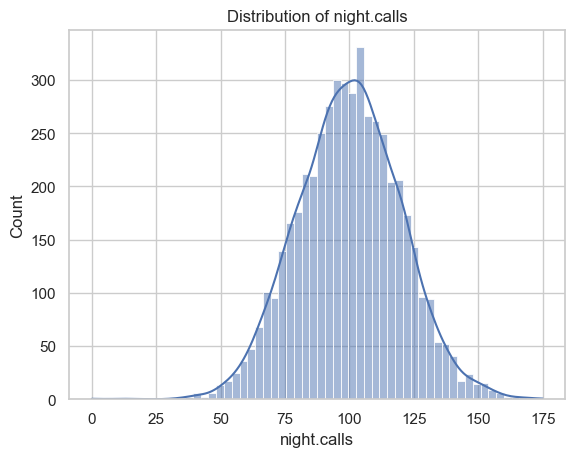

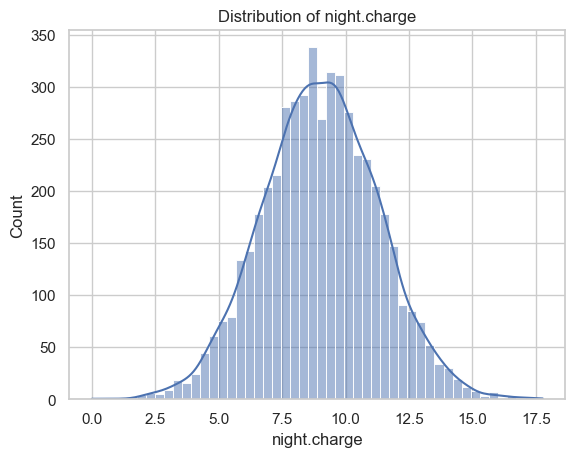

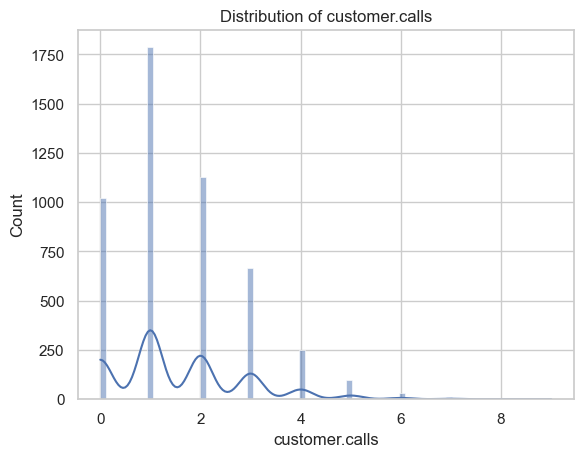

In [11]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

### Bivariant Analysis

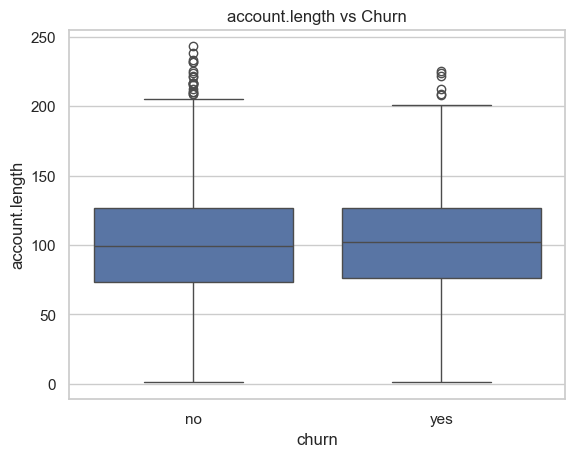

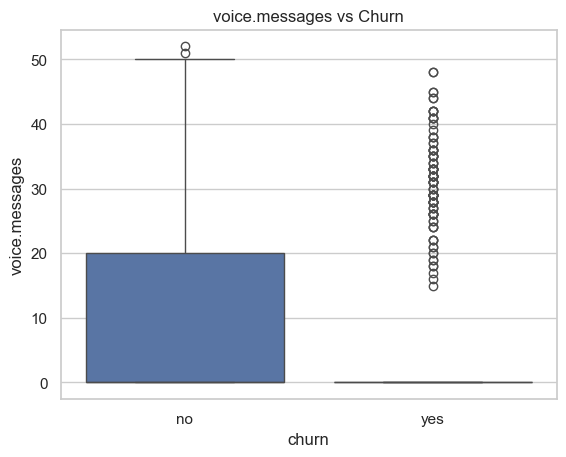

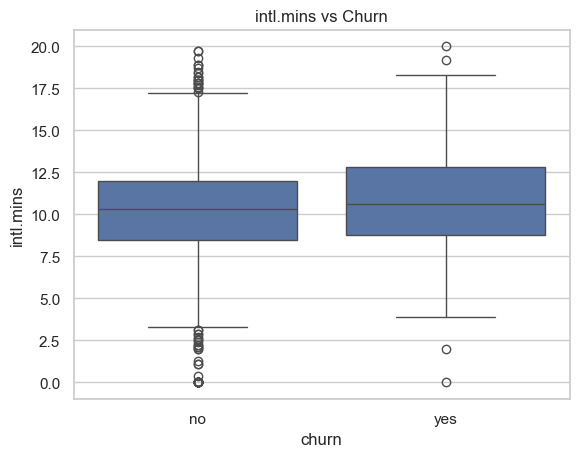

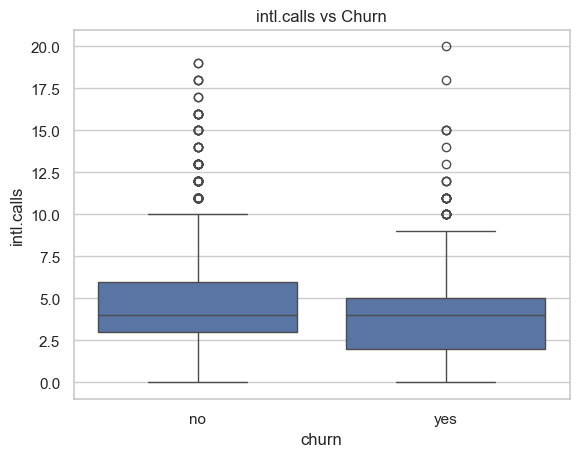

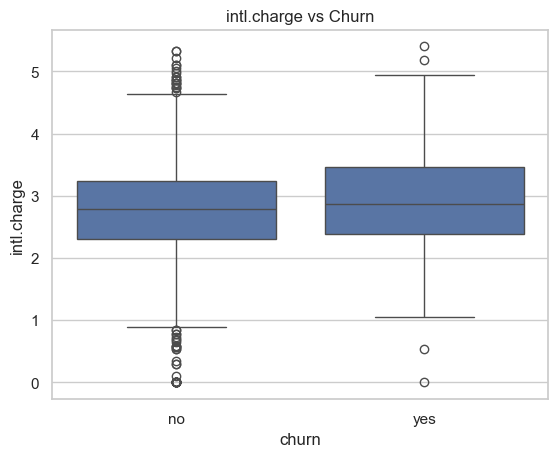

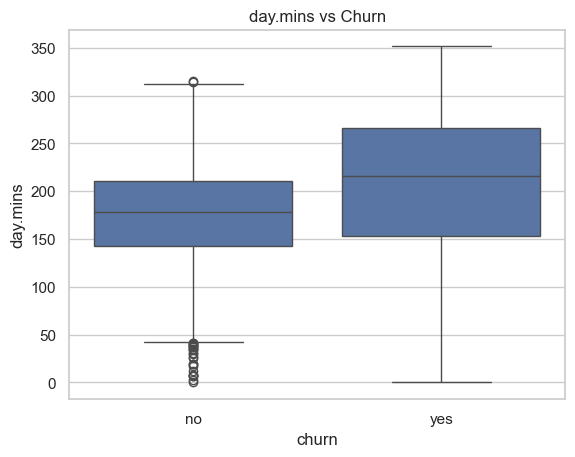

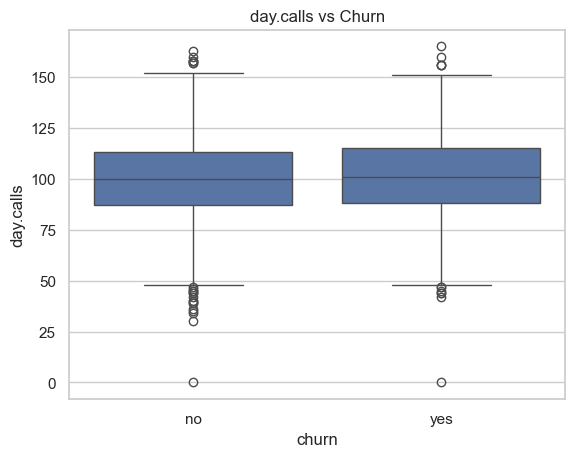

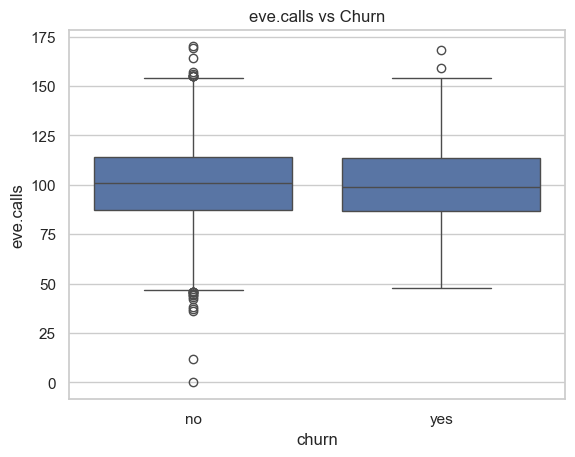

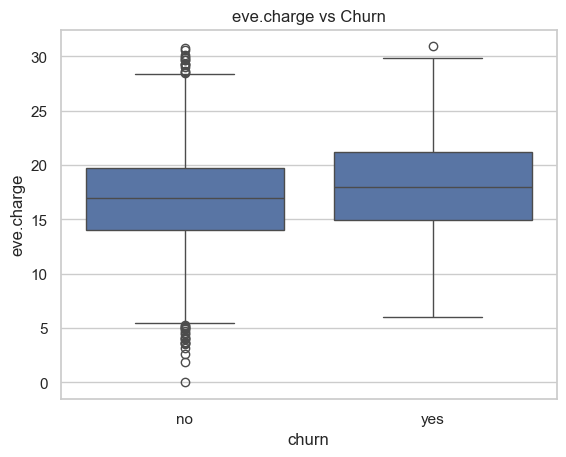

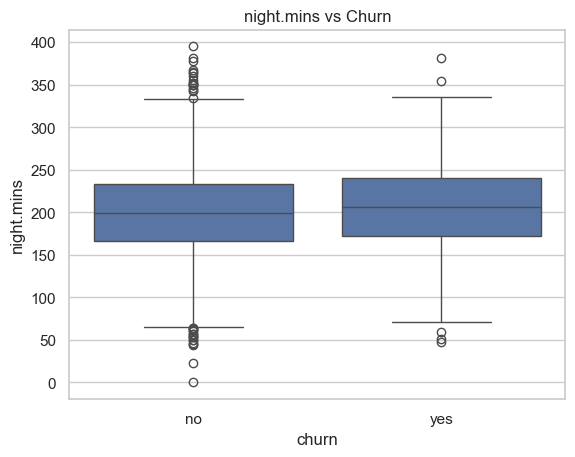

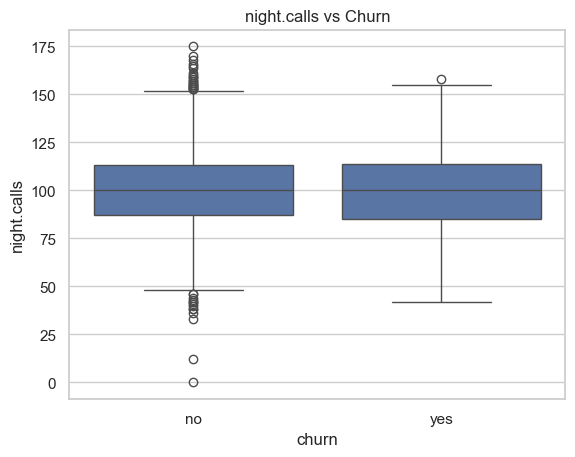

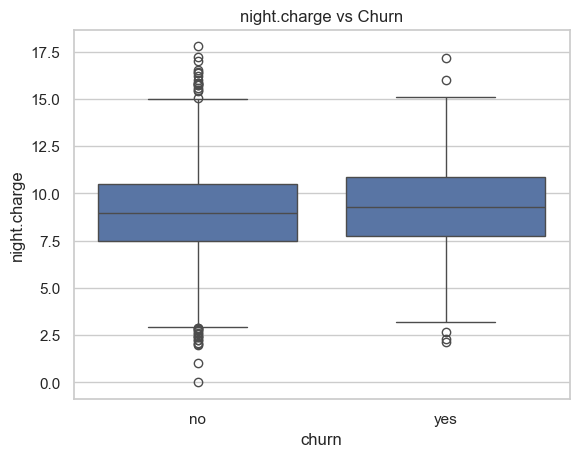

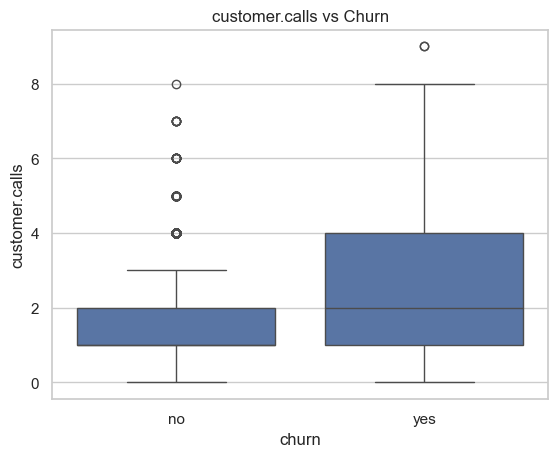

In [12]:
for col in num_cols:
    if col != 'churn':
        plt.figure()
        sns.boxplot(x='churn', y=col, data=df)
        plt.title(f"{col} vs Churn")
        plt.show()

### Categorical vs Target

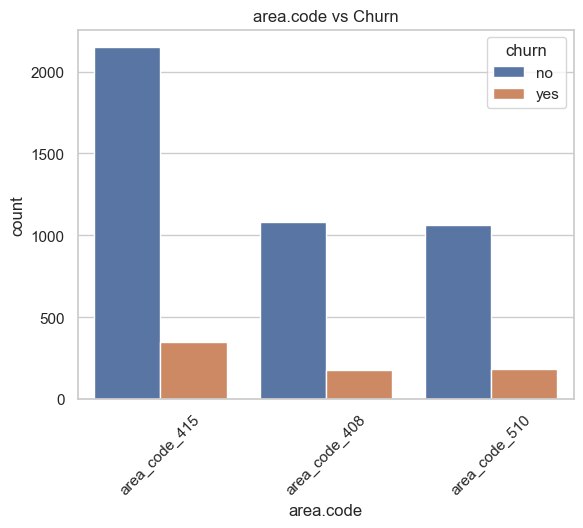

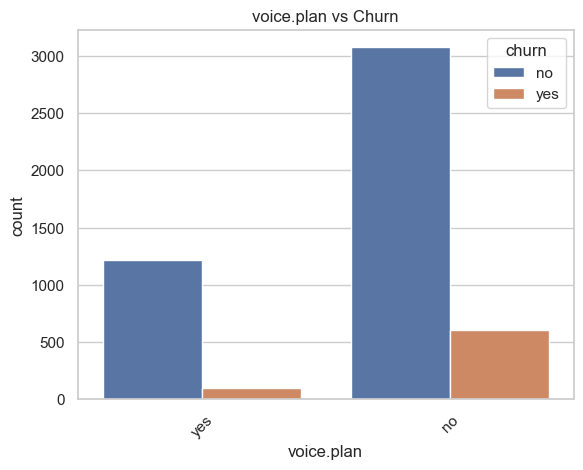

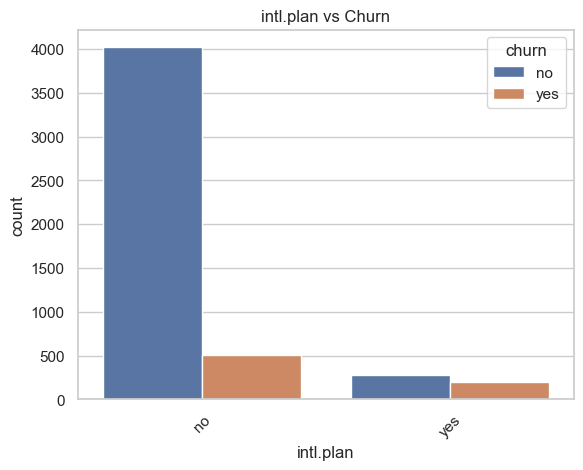

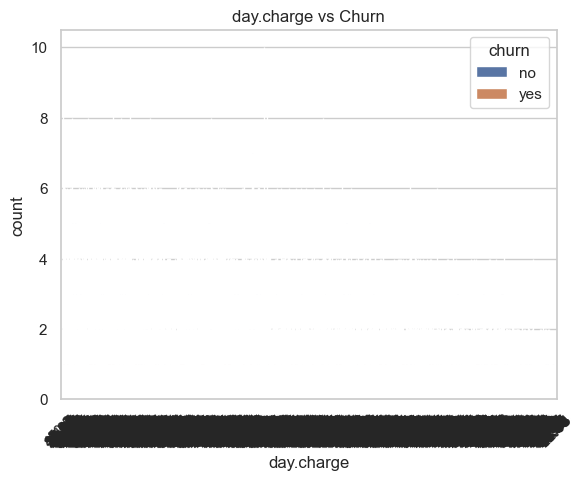

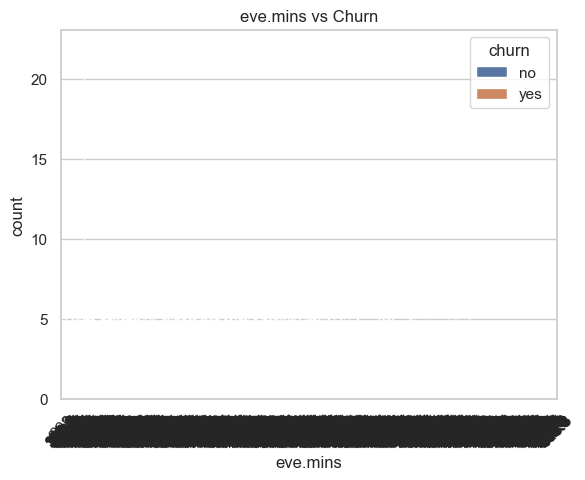

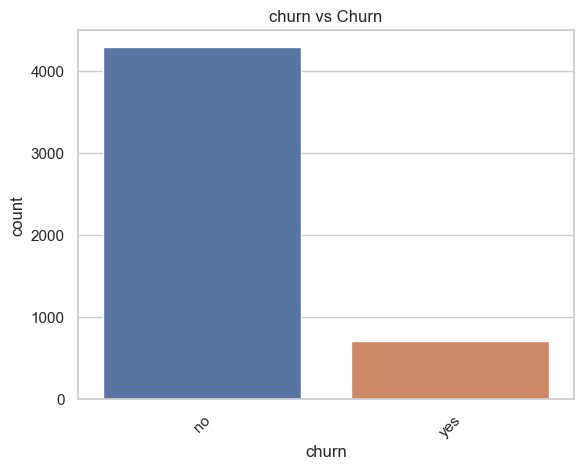

In [13]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure()
    sns.countplot(x=col, hue='churn', data=df)
    plt.title(f"{col} vs Churn")
    plt.xticks(rotation=45)
    plt.show()

### Outlier Checking

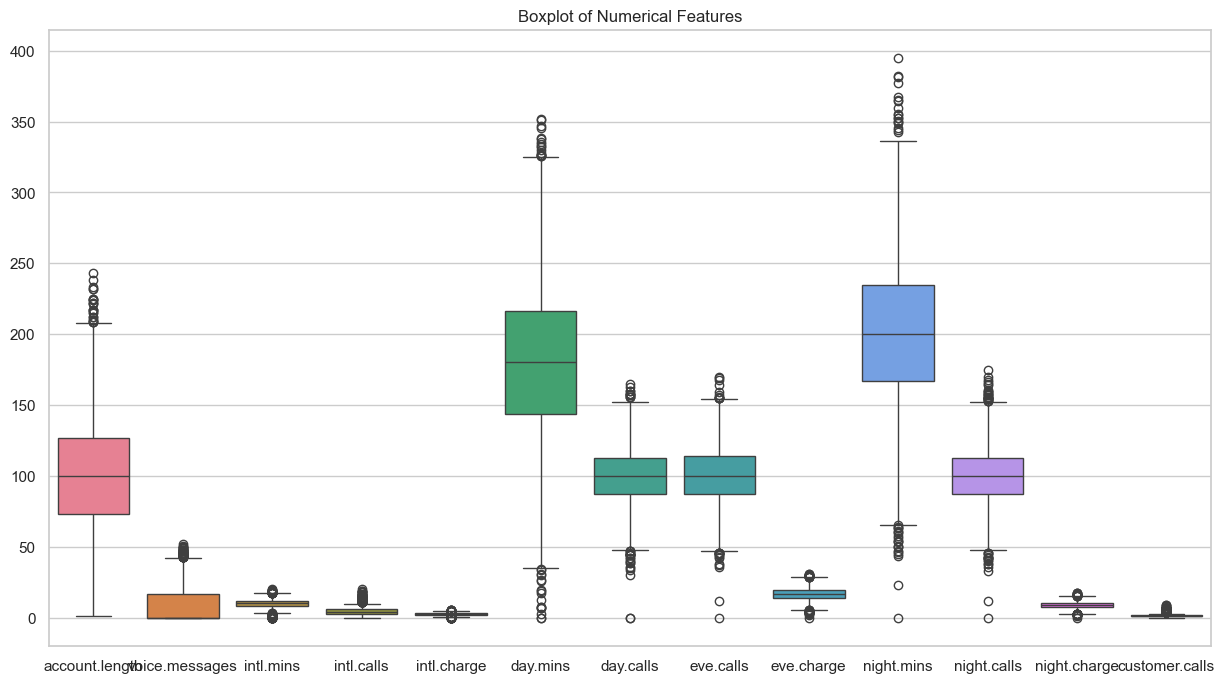

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(15,8))
sns.boxplot(data=df.select_dtypes(include=['int64', 'float64']))
plt.title("Boxplot of Numerical Features")
plt.show()

In [15]:
### outlier capping

def outlier_capping(df,column):

    Q1= df[column].quantile(0.25)

    Q3= df[column].quantile(0.75)
    IQR= Q3-Q1
    lower_extreme= Q1-1.5*IQR

    upper_extreme= Q3+ 1.5*IQR

    df[column]= df[column].apply(lambda x:lower_extreme if x< lower_extreme else upper_extreme if x>upper_extreme else x)

for col in df.select_dtypes(include=['int','float']).columns:

    outlier_capping(df,col)

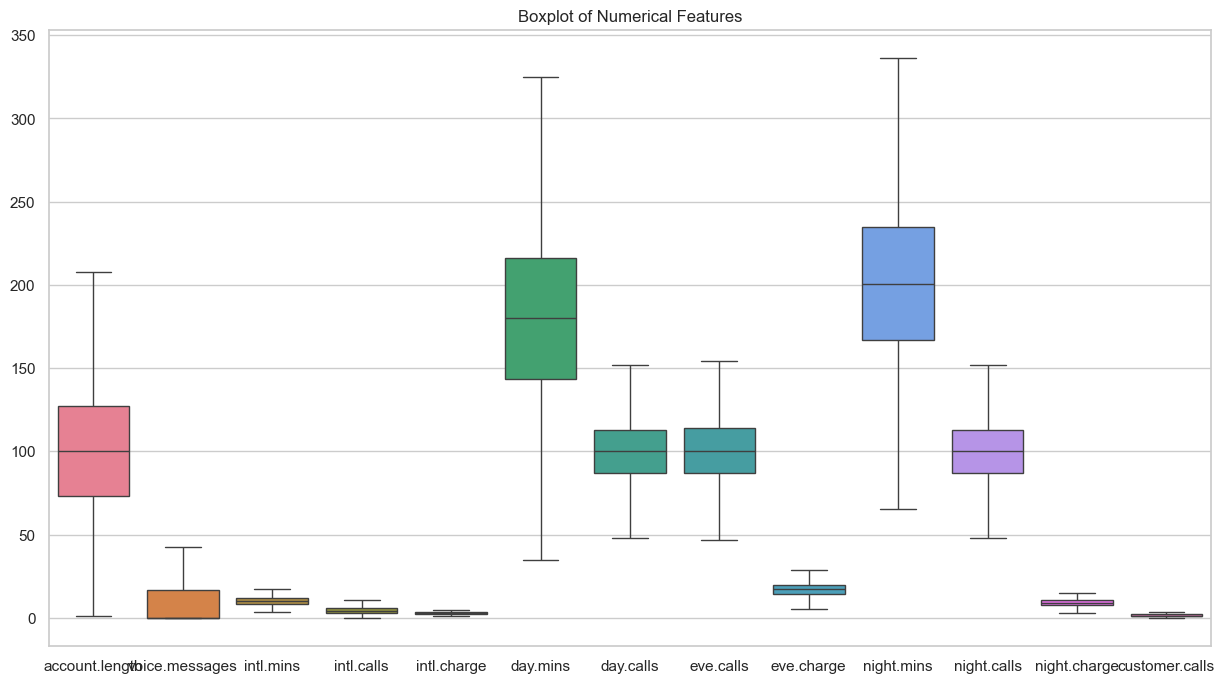

In [16]:
### No outlier present after caping
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(15,8))
sns.boxplot(data=df.select_dtypes(include=['int64', 'float64']))
plt.title("Boxplot of Numerical Features")
plt.show()

### Correlation Heatmap

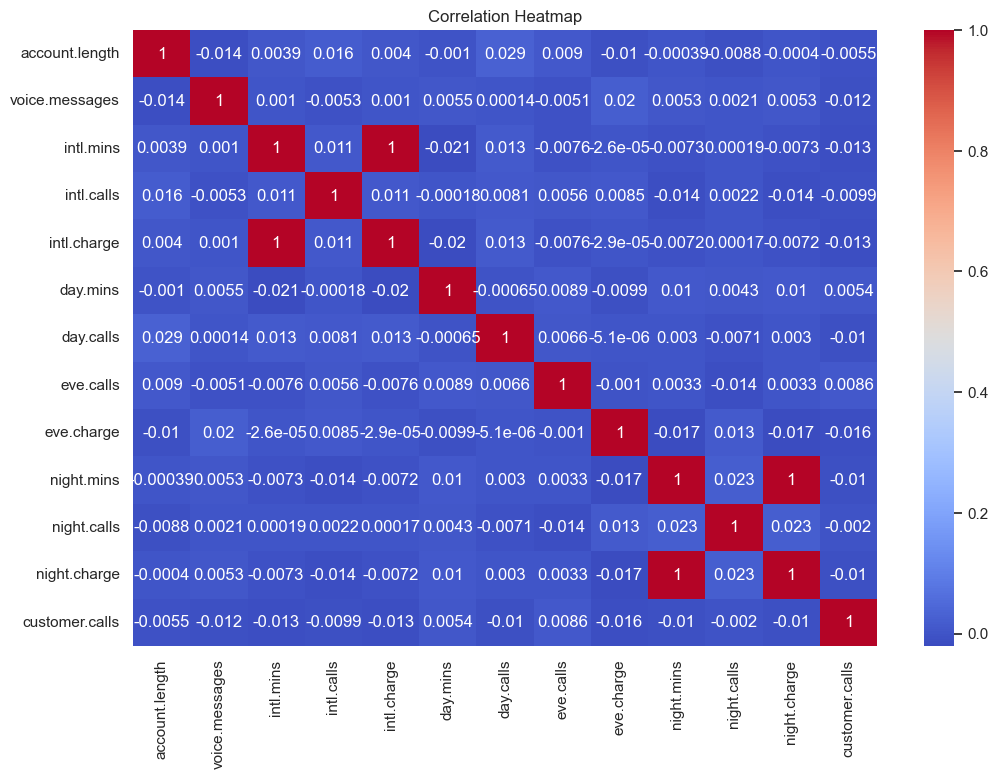

In [17]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### Feature Selection

In [19]:
# Features
X = df.drop('churn', axis=1)

# Target
y = df['churn']

## Feature Scaling

In [26]:
from sklearn.preprocessing import StandardScaler

# Convert categorical columns to numeric
X = pd.get_dummies(X, drop_first=True)

# Scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame (optional)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(X_scaled.head())

   account.length  voice.messages  intl.mins  intl.calls  intl.charge  \
0        0.703644        1.284860  -0.102827   -0.609569    -0.103687   
1        0.172149        1.359216   1.276052   -0.609569     1.277445   
2        0.931427       -0.574045   0.717047    0.273608     0.711181   
3       -0.409965       -0.574045  -1.369905    1.156785    -1.374328   
4       -0.637749       -0.574045  -0.065560   -0.609569    -0.062253   

   day.mins  day.calls  eve.calls  eve.charge  night.mins  ...  \
0  1.581475   0.506326  -0.061097   -0.064857    0.885268  ...   
1 -0.349143   1.168469   0.141967   -0.102375    1.078953  ...   
2  1.176698   0.710062   0.497330   -1.584336   -0.754062  ...   
3  2.221284  -1.480104  -0.619524   -2.709876   -0.069177  ...   
4 -0.254011   0.659128   1.106523   -1.042670   -0.268852  ...   

   eve.mins_349.4  eve.mins_350.5  eve.mins_350.9  eve.mins_351.6  \
0       -0.014144       -0.014144       -0.014144       -0.014144   
1       -0.014144       -0

In [27]:
X_scaled

,account.length,voice.messages,intl.mins,intl.calls,intl.charge,day.mins,day.calls,eve.calls,eve.charge,night.mins,...,eve.mins_349.4,eve.mins_350.5,eve.mins_350.9,eve.mins_351.6,eve.mins_352.1,eve.mins_354.2,eve.mins_359.3,eve.mins_361.8,eve.mins_363.7,eve.mins_Nan
0,0.703644,1.284860,-0.102827,-0.609569,-0.103687,1.581475,0.506326,-0.061097,-0.064857,0.885268,...,-0.014144,-0.014144,-0.014144,-0.014144,-0.014144,-0.014144,-0.014144,-0.014144,-0.014144,-0.069449
1,0.172149,1.359216,1.276052,-0.609569,1.277445,-0.349143,1.168469,0.141967,-0.102375,1.078953,...,-0.014144,-0.014144,-0.014144,-0.014144,-0.014144,-0.014144,-0.014144,-0.014144,-0.014144,-0.069449
2,0.931427,-0.574045,0.717047,0.273608,0.711181,1.176698,0.710062,0.497330,-1.584336,-0.754062,...,-0.014144,-0.014144,-0.014144,-0.014144,-0.014144,-0.014144,-0.014144,-0.014144,-0.014144,-0.069449
3,-0.409965,-0.574045,-1.369905,1.156785,-1.374328,2.221284,-1.480104,-0.619524,-2.709876,-0.069177,...,-0.014144,-0.014144,-0.014144,-0.014144,-0.014144,-0.014144,-0.014144,-0.014144,-0.014144,-0.069449
4,-0.637749,-0.574045,-0.065560,-0.609569,-0.062253,-0.254011,0.659128,1.106523,-1.042670,-0.268852,...,-0.014144,-0.014144,-0.014144,-0.014144,-0.014144,-0.014144,-0.014144,-0.014144,-0.014144,-0.069449
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,-1.270481,2.400203,-0.140094,0.273608,-0.145121,1.033068,1.372206,1.309587,0.446325,1.939551,...,-0.014144,-0.014144,-0.014144,-0.014144,-0.014144,-0.014144,-0.014144,-0.014144,-0.014144,-0.069449
4996,1.311067,-0.574045,1.648722,-1.051157,1.650350,0.072422,-0.512356,-1.381015,1.119304,0.264280,...,-0.014144,-0.014144,-0.014144,-0.014144,-0.014144,-0.014144,-0.014144,-0.014144,-0.014144,-0.069449
4997,-0.992079,-0.574045,1.238785,-0.167980,1.236011,-0.740862,-0.563290,1.411119,-0.554936,0.240319,...,-0.014144,-0.014144,-0.014144,-0.014144,-0.014144,-0.014144,-0.014144,-0.014144,-0.014144,-0.069449
4998,0.222767,-0.574045,-0.661832,0.715197,-0.656140,0.158227,-1.683841,-0.416460,-0.578385,0.479928,...,-0.014144,-0.014144,-0.014144,-0.014144,-0.014144,-0.014144,-0.014144,-0.014144,-0.014144,-0.069449


### Final Summary

In [28]:
print("Final Dataset Shape:", df.shape)
print("Number of Features:", df.shape[1] - 1)
print("Target Distribution:\n", df['churn'].value_counts())

Final Dataset Shape: (5000, 19)
Number of Features: 18
Target Distribution:
 churn
no     4293
yes     707
Name: count, dtype: int64


### Final Output

In [29]:
print("Columns:", df.columns)
df.head()

Columns: Index(['area.code', 'account.length', 'voice.plan', 'voice.messages',
       'intl.plan', 'intl.mins', 'intl.calls', 'intl.charge', 'day.mins',
       'day.calls', 'day.charge', 'eve.mins', 'eve.calls', 'eve.charge',
       'night.mins', 'night.calls', 'night.charge', 'customer.calls', 'churn'],
      dtype='object')


,area.code,account.length,voice.plan,voice.messages,intl.plan,intl.mins,intl.calls,intl.charge,day.mins,day.calls,day.charge,eve.mins,eve.calls,eve.charge,night.mins,night.calls,night.charge,customer.calls,churn
0,area_code_415,128.0,yes,25.0,no,10.0,3.0,2.70,265.1,110.0,45.07,197.4,99.0,16.78,244.7,91.0,11.01,1.0,no
1,area_code_415,107.0,yes,26.0,no,13.7,3.0,3.70,161.6,123.0,27.47,195.5,103.0,16.62,254.4,103.0,11.45,1.0,no
2,area_code_415,137.0,no,0.0,no,12.2,5.0,3.29,243.4,114.0,41.38,121.2,110.0,10.30,162.6,104.0,7.32,0.0,no
3,area_code_408,84.0,no,0.0,yes,6.6,7.0,1.78,299.4,71.0,50.9,61.9,88.0,5.50,196.9,89.0,8.86,2.0,no
4,area_code_415,75.0,no,0.0,yes,10.1,3.0,2.73,166.7,113.0,28.34,148.3,122.0,12.61,186.9,121.0,8.41,3.0,no


## Train-test Split

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Model Building

### 1. Logistic Regression

In [31]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)



### 2. Decision Tree Classifier

In [32]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

### 3. Random Forest Classifier

In [33]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

### 4. KNN Classifier

In [ ]:
import warnings
warnings.filterwarnings("ignore")

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

### 5. Support Vector Machine (SVM)

In [35]:
from sklearn.svm import SVC

svm_model = SVC()

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

## Model Evaluation

In [36]:
# Accuracy Calculation
from sklearn.metrics import accuracy_score

log_accuracy = accuracy_score(y_test, log_pred)

dt_accuracy = accuracy_score(y_test, dt_pred)

rf_accuracy = accuracy_score(y_test, rf_pred)

knn_accuracy = accuracy_score(y_test, knn_pred)

svm_accuracy = accuracy_score(y_test, svm_pred)


# Model Comparison

In [37]:
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'KNN',
        'SVM'
        
    ],

    'Accuracy': [
        log_accuracy,
        dt_accuracy,
        rf_accuracy,
        knn_accuracy,
        svm_accuracy
    ]
})

print(comparison)

                 Model  Accuracy
0  Logistic Regression     0.867
1        Decision Tree     0.930
2        Random Forest     0.908
3                  KNN     0.870
4                  SVM     0.861


## Hyperparameter Tuning

In [38]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Random Forest Model
rf_model = RandomForestClassifier(random_state=42)

# Hyperparameters
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Train
grid_search.fit(X_train, y_train)

# Best Parameters
print("Best Parameters:")
print(grid_search.best_params_)

# Best Model
best_rf = grid_search.best_estimator_

# Predictions
best_pred = best_rf.predict(X_test)

# Final Accuracy
final_accuracy = accuracy_score(y_test, best_pred)

print("Final Accuracy:", final_accuracy)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 50}
Final Accuracy: 0.904


## Model Evaluation Graphs

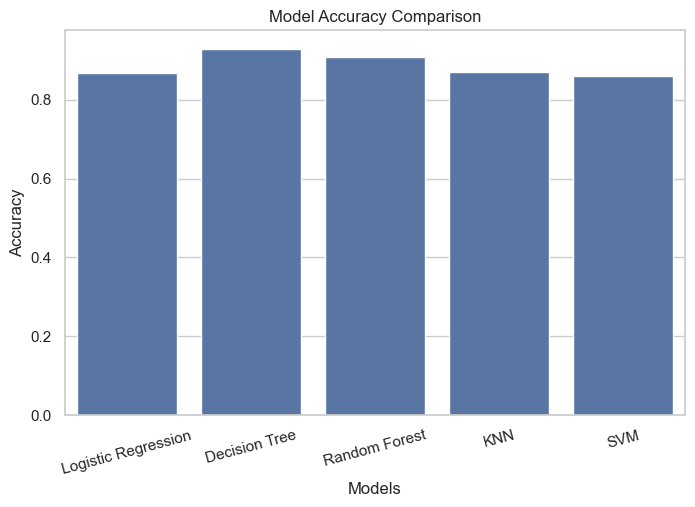

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=comparison
)

plt.title("Model Accuracy Comparison")

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.xticks(rotation=15)

plt.show()

In [40]:
# Accuracy
from sklearn.metrics import accuracy_score

final_accuracy = accuracy_score(
    y_test,
    best_pred
)

print("Final Accuracy:", final_accuracy)

Final Accuracy: 0.904


In [41]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    best_pred
)

print(cm)

[[857   4]
 [ 92  47]]


## Note:

### 2.Confusion Matrix Heatmap

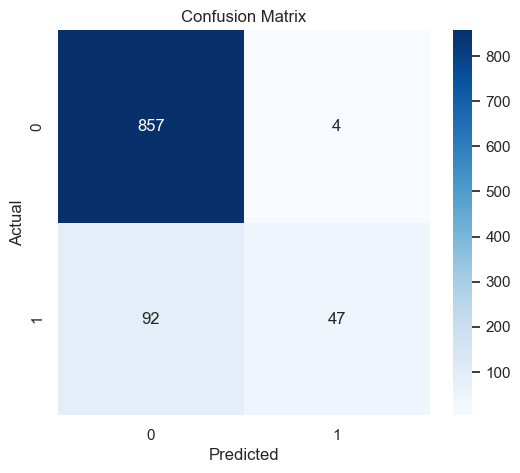

In [42]:
from sklearn.metrics import confusion_matrix

# Confusion Matrix
cm = confusion_matrix(y_test, best_pred)

# Plot
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

## ROC Curve

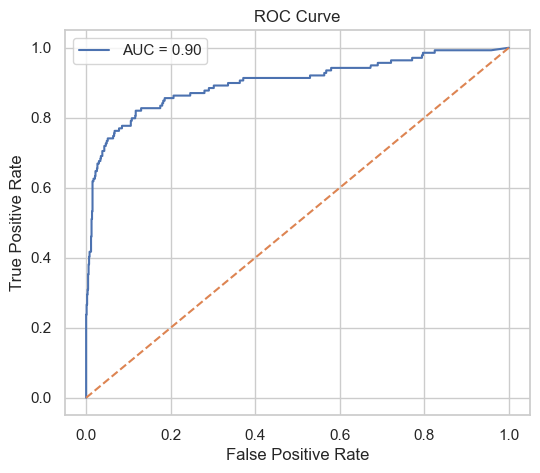

In [44]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probabilities
y_prob = best_rf.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob,
    pos_label='yes'
)

# AUC score
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

## Feature Importance Graph

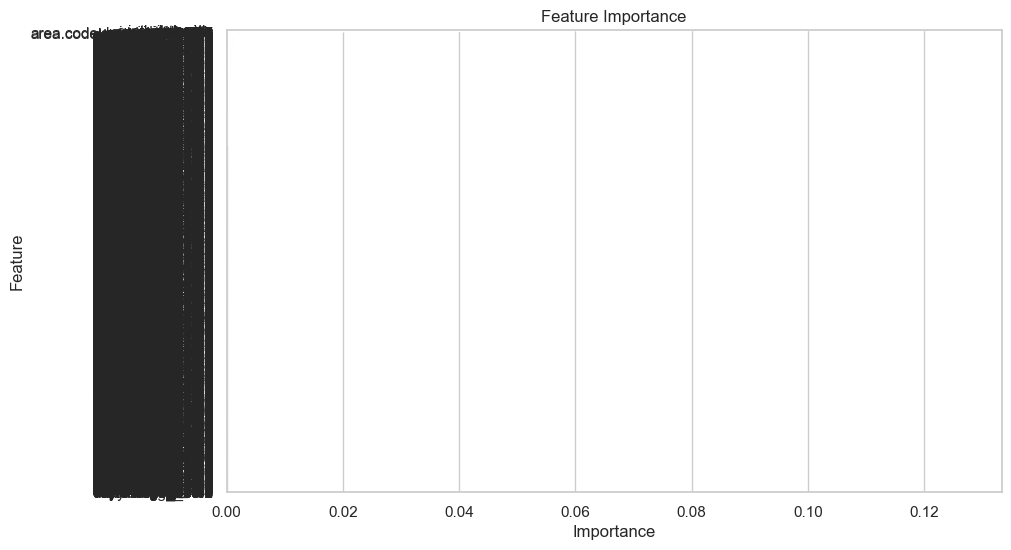

In [46]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance")

plt.show()

In [47]:
# Classification Report
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        best_pred
    )
)

              precision    recall  f1-score   support

          no       0.90      1.00      0.95       861
         yes       0.92      0.34      0.49       139

    accuracy                           0.90      1000
   macro avg       0.91      0.67      0.72      1000
weighted avg       0.91      0.90      0.88      1000



## Classification Report Heatmap

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    best_pred,
    output_dict=True
)

import pandas as pd

report_df = pd.DataFrame(report).transpose()

plt.figure(figsize=(8,5))

sns.heatmap(
    report_df.iloc[:-1, :-1],
    annot=True,
    cmap='Blues'
)

plt.title("Classification Report Heatmap")

plt.show()